Feature scaling is a techinique to standardize the independent features present in the data ina  fixed range .

feature scaling is of two types :
A. Standardization  or Z-score normalization                B. Normalization

during standardization , we replace the current data values xi with xi_ = xi - x_mean / sigma 



where xi = current x value 
      x_mean = mean of all the values of that feature 
      sigma = standard deviation 

     # such that mean of new  data becomes 0 and standard deviation becomes 1 across both scales.

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')


In [3]:
#df = df.iloc[: , 2:]

In [4]:
#df.sample(5)

In [5]:
df.head() #categprical dataset 

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


Train Test split

When you build an ML model, you need to answer two questions:

Does the model learn the patterns in data?
Will it work on new, unseen data it's never encountered?

If you test on the same data you trained on, you can't answer question 2 — the model might have just memorized the answers rather than learning real patterns. That's called overfitting.
So the solution is to split your data into two separate buckets before training:
                      Train Set                       Test Set
What it is:   The data the model learns from      Data held back, never seen during                                          training.





Used for :       Fitting the model                Evaluating how well it generalizes





Typical size :       80% of your data                20% of your data

Train Test Split 

In [19]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train, y_test = train_test_split(df.drop('Purchased', axis = 1) , df['Purchased'] , test_size = 0.3 , random_state = 0)  # X — all feature columns
                    # y — ONLY the target column


x_train.shape , x_test.shape


((280, 2), (120, 2))

Standard Scaler

In [8]:
#the exact tool to perform standardization using the above mentioned formula .

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fit the scaler to the train set , it will learn the parameters

scaler.fit(x_train , y_train) # learns mean, std of x_train


#transform train and test sets

x_train_scaled = scaler.transform(x_train) # now scales using learned mean/std
x_test_scaled = scaler.transform(x_test) # scales x_test using SAME mean/std



In [9]:
scaler.mean_


array([3.78642857e+01, 6.98071429e+04])

In [20]:
#the input data is a dataframe
x_train.head()


,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


In [21]:
#the scaled output data was an array [ age , salary]
x_train_scaled.head()


,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


In [12]:
x_test


,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000
...,...,...
216,49,65000
259,45,131000
49,31,89000
238,46,82000


In [13]:
#hence we convert the scaled data into a dataframe too.
x_train_scaled = pd.DataFrame(x_train_scaled , columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns = x_test.columns)

In [14]:
x_train_scaled


,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [15]:
np.round(x_train_scaled.describe() , 1)
#it can be clearly seen that the mean has become 0 after scaling and std is 1 .

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


Effect of scaling

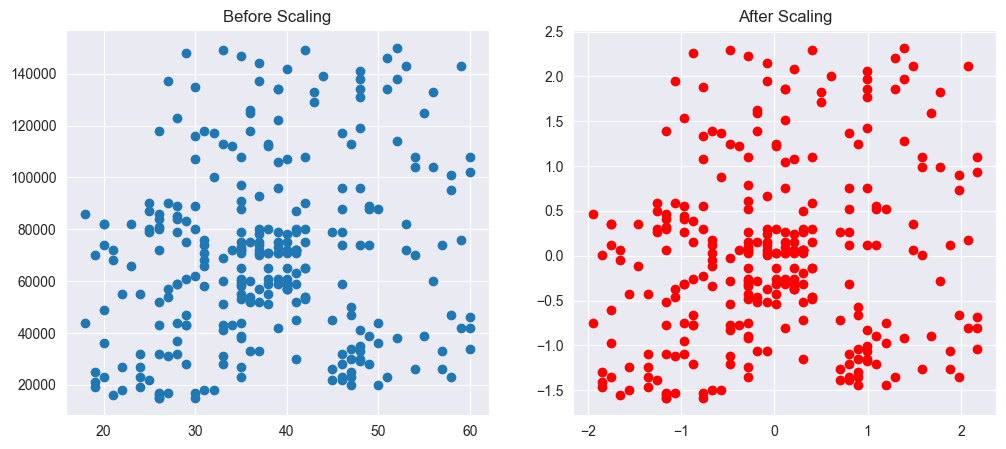

In [16]:
fig ,(ax1 , ax2) = plt.subplots(ncols = 2  , figsize=(12 , 5 ))
ax1.scatter(x_train['Age'] ,x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'] , color = 'red')
ax2.set_title("After Scaling")
plt.show()
#data has been centred after scaling


In [17]:
np.round(x_test_scaled.describe() ,1)


,Age,EstimatedSalary
count,120.0,120.0
mean,-0.1,-0.0
std,1.1,1.0
min,-1.9,-1.6
25%,-1.0,-0.7
50%,-0.2,-0.2
75%,0.7,0.5
max,2.2,2.3


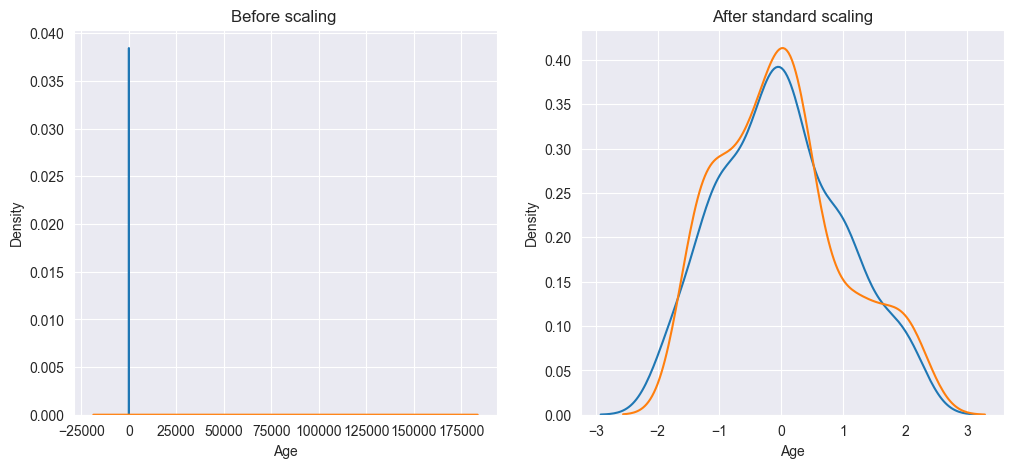

In [18]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2 , figsize = (12, 5))

#before scaling
ax1.set_title('Before scaling ')
sns.kdeplot(x_train['Age'] , ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'] , ax = ax1)

#after scaling
ax2.set_title('After standard scaling')
sns.kdeplot(x_train_scaled['Age'] , ax = ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax = ax2)
plt.show()

Comparison of distributions

outliers are not affected by standardization

algos where standardzization must be used :-
k means
knn
pca
artificial neural network
gradient descent